# Toneleaf: Private Sentiment Analysis

This notebook demonstrates Toneleaf's device-local Python NLP engine for **positive, neutral, and negative polarity** plus a separate **distress-language screening** mode. It uses no remote inference API and does not upload text.

> Percentages are deterministic language-signal shares, not calibrated probabilities. Distress screening is not a diagnosis.

## 1. Load the local engine

The engine uses an offline transformer only when `TONELEAF_MODEL_PATH` points to existing model files. Otherwise it uses the explainable Python fallback demonstrated here.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'backend').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from backend.engine import analyze_distress, analyze_polarity

print(f'Project root: {ROOT}')
print(f'Engine: {analyze_polarity("Toneleaf is helpful")["engine"]}')

Project root: C:\Users\Saanvi\Downloads\Sentiment
Engine: python-local-lexicon


## 2. Analyze representative sentences

These examples cover favorable language, factual text, negation, criticism, insults, and directed threats.

In [2]:
examples = [
    'I absolutely love this wonderful result!',
    'The meal was delicious and the staff were friendly.',
    'This is not bad at all.',
    'The meeting starts at three oâ€™clock.',
    'The package weighs two kilograms.',
    'This is not good enough.',
    'You are disgusting.',
    'I am going to hurt you.',
    'I feel hopeless, lonely, and worthless.',
]

rows = []
for text in examples:
    result = analyze_polarity(text)
    rows.append({
        'text': text,
        'label': result['label'],
        'positive': result['scores']['positive'],
        'neutral': result['scores']['neutral'],
        'negative': result['scores']['negative'],
        'cues': ', '.join(result['cues']) or 'â€”',
    })
example_df = pd.DataFrame(rows)
example_df

,text,label,positive,neutral,negative,cues
0,I absolutely love this wonderful result!,positive,87,13,0,"love, wonderful"
1,The meal was delicious and the staff were frie...,positive,79,21,0,"delicious, friendly"
2,This is not bad at all.,positive,59,41,0,bad
3,The meeting starts at three oâ€™clock.,neutral,0,100,0,â€”
4,The package weighs two kilograms.,neutral,0,100,0,â€”
5,This is not good enough.,negative,0,22,78,"not good enough, good"
6,You are disgusting.,negative,0,26,74,disgusting
7,I am going to hurt you.,negative,0,14,86,"hurt you, hurt"
8,"I feel hopeless, lonely, and worthless.",negative,0,12,88,"worthless, hopeless, lonely"


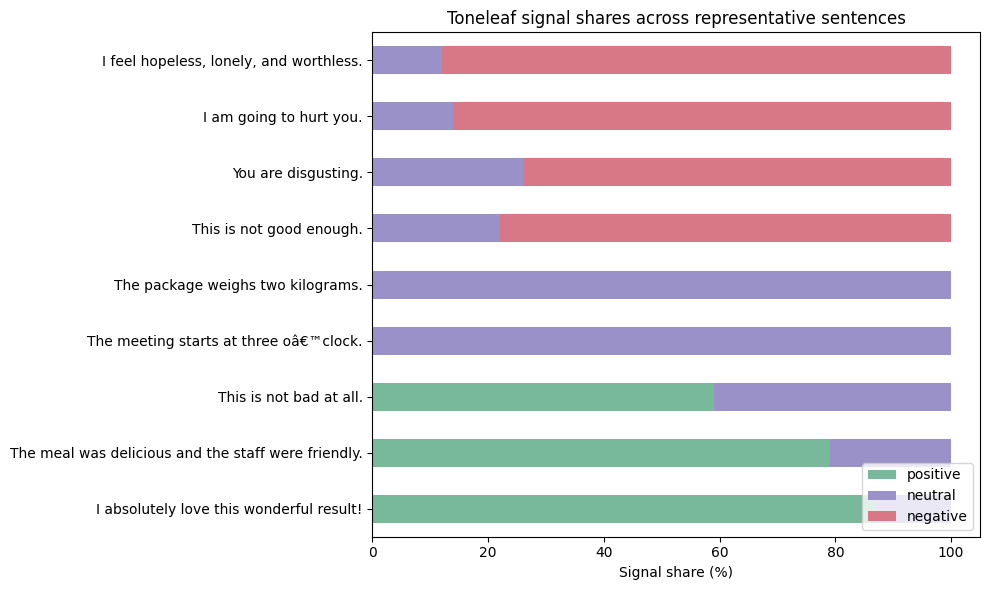

In [3]:
ax = example_df.set_index('text')[['positive', 'neutral', 'negative']].plot(
    kind='barh', stacked=True, figsize=(10, 6),
    color=['#79b99b', '#9b91c9', '#d87886']
)
ax.set_title('Toneleaf signal shares across representative sentences')
ax.set_xlabel('Signal share (%)')
ax.set_ylabel('')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Evaluate more than 30 labelled sentences

The repository includes a human-labelled smoke corpus spanning positive, neutral, negative, negated, insulting, threatening, and distress-related language. This is regression coverageâ€”not a claim of universal model accuracy.

In [4]:
from tests.evaluation_cases import POLARITY_CASES

evaluation_rows = []
for text, expected in POLARITY_CASES:
    result = analyze_polarity(text)
    evaluation_rows.append({
        'text': text,
        'expected': expected,
        'predicted': result['label'],
        'confidence': result['confidence'],
        'correct': result['label'] == expected,
    })
evaluation_df = pd.DataFrame(evaluation_rows)
accuracy = evaluation_df['correct'].mean()
print(f'Correct: {evaluation_df["correct"].sum()}/{len(evaluation_df)}')
print(f'Curated-corpus accuracy: {accuracy:.1%}')
evaluation_df.head(10)

Correct: 42/42
Curated-corpus accuracy: 100.0%


,text,expected,predicted,confidence,correct
0,I absolutely love this wonderful result!,positive,positive,87,True
1,The meal was delicious and the staff were frie...,positive,positive,79,True
2,I am delighted with the excellent service.,positive,positive,73,True
3,What a pleasant and thoughtful surprise.,positive,positive,82,True
4,You did an outstanding job and I am proud of you.,positive,positive,81,True
5,Thank you for being so kind and helpful.,positive,positive,84,True
6,Everything worked perfectly and the process wa...,positive,positive,79,True
7,"I feel grateful, hopeful, and supported.",positive,positive,78,True
8,This is not bad at all.,positive,positive,59,True
9,I do not hate the new design.,positive,positive,69,True


In [5]:
confusion = pd.crosstab(
    evaluation_df['expected'], evaluation_df['predicted'],
    rownames=['Expected'], colnames=['Predicted'], dropna=False,
).reindex(index=['positive', 'neutral', 'negative'], columns=['positive', 'neutral', 'negative'], fill_value=0)
confusion

Predicted,positive,neutral,negative
Expected,,,
positive,12,0,0
neutral,0,12,0
negative,0,0,18


In [6]:
class_summary = evaluation_df.groupby('expected').agg(
    sentences=('text', 'size'),
    correct=('correct', 'sum'),
    mean_confidence=('confidence', 'mean'),
).reindex(['positive', 'neutral', 'negative'])
class_summary['accuracy'] = class_summary['correct'] / class_summary['sentences']
class_summary

,sentences,correct,mean_confidence,accuracy
expected,,,,
positive,12,12,76.000000,1.0
neutral,12,12,100.000000,1.0
negative,18,18,81.944444,1.0


## 4. Distress-language screening

This mode screens self-directed distress language separately from ordinary negativity or directed threats. A supportive result does **not** guarantee safety, and a distress result does **not** establish a mental-health condition.

In [7]:
distress_examples = [
    'I feel calm and supported today.',
    'The meeting starts at three oâ€™clock.',
    'I feel hopeless and want to die.',
    'I cannot go on and I want to end my life.',
    'I feel trapped, worthless, and completely alone.',
    'I will kill you.',
]
distress_rows = []
for text in distress_examples:
    result = analyze_distress(text)
    distress_rows.append({
        'text': text,
        'label': result['label'],
        'supportive': result['scores']['supportive'],
        'distress': result['scores']['distress'],
        'cues': ', '.join(result['cues']) or 'â€”',
    })
pd.DataFrame(distress_rows)

,text,label,supportive,distress,cues
0,I feel calm and supported today.,supportive,95,5,â€”
1,The meeting starts at three oâ€™clock.,supportive,95,5,â€”
2,I feel hopeless and want to die.,distress,4,96,"want to die, die, hopeless"
3,I cannot go on and I want to end my life.,distress,4,96,"end my life, cannot go on"
4,"I feel trapped, worthless, and completely alone.",distress,10,90,"worthless, trapped, alone"
5,I will kill you.,supportive,71,29,â€”


## 5. Interpretation and limitations

- The fallback engine is deterministic and explainable, but vocabulary-based.
- Negation, intensifiers, common threats, insults, and distress phrases are handled explicitly.
- Sarcasm, coded language, cultural nuance, and long conversational context remain difficult.
- The 42-sentence result above measures a curated regression corpus, not population-level accuracy.
- Hosted deployment processes text transiently on the operator's server over HTTPS; device-local mode provides the strongest privacy boundary.
- Never use Toneleaf alone for clinical, employment, moderation, legal, or emergency decisions.